#Fine-Tuning BERT for Sentiment Analysis

Step 1 — Set Up Environment

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report

from datasets import load_dataset
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer,
)
import torch

Step 2 — Import BERT-base

In [ ]:
MODEL_NAME = "bert-base-uncased"

print("Loading tokenizer and model...")
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Loading tokenizer and model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model parameters: 109,483,778


Step 3 — Load the Dataset


In [ ]:
print("\nLoading SST-2 dataset...")
dataset = load_dataset("sst2")

print(f"Train examples   : {len(dataset['train']):,}")
print(f"Validation examples: {len(dataset['validation']):,}")
print(f"\nSample entry: {dataset['train'][0]}")


Loading SST-2 dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Train examples   : 67,349
Validation examples: 872

Sample entry: {'idx': 0, 'sentence': 'hide new secretions from the parental units ', 'label': 0}


Step 4 — Tokenize the Data

In [ ]:
MAX_LENGTH = 128

def tokenize(batch):
    return tokenizer(
        batch["sentence"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
    )

print("\nTokenizing dataset...")
tokenized_dataset = dataset.map(tokenize, batched=True)
tokenized_dataset.set_format(
    "torch", columns=["input_ids", "attention_mask", "label"]
)


Tokenizing dataset...


Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]

Step 5 — Train the Model

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1"      : f1_score(labels, predictions, average="weighted"),
    }

In [ ]:
EPOCHS     = 3
BATCH_SIZE = 16
LR         = 2e-5          # default AdamW lr used by Trainer

training_args = TrainingArguments(
    output_dir                  = "./results",
    num_train_epochs            = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = 32,
    learning_rate               = LR,
    optim                       = "adamw_torch",
    warmup_steps                = 500,              # ~10 % of steps for LR warm-up
    weight_decay                = 0.01,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "accuracy",
    logging_steps               = 100,
    report_to                   = "none",           # disable W&B / MLflow
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = tokenized_dataset["train"],
    eval_dataset    = tokenized_dataset["validation"],
    compute_metrics = compute_metrics,
)

In [ ]:
print("\n" + "="*60)
print("Starting training …")
print("="*60)

train_output = trainer.train()

print("\nTraining complete!")
print(f"  Total training time  : {train_output.metrics['train_runtime']:.1f}s")
print(f"  Train samples/second : {train_output.metrics['train_samples_per_second']:.1f}")


Starting training …


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.167307,0.267798,0.923165,0.923155
2,0.079968,0.363189,0.912844,0.912702
3,0.060936,0.362255,0.925459,0.925443


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Training complete!
  Total training time  : 4502.4s
  Train samples/second : 44.9


Step 6 — Evaluate and Report


In [ ]:
print("\n" + "="*60)
print("Evaluating on validation set …")
print("="*60)

results = trainer.evaluate()
print(f"\n  Validation loss     : {results['eval_loss']:.4f}")
print(f"  Validation accuracy : {results['eval_accuracy']:.4f} ({results['eval_accuracy']*100:.2f}%)")
print(f"  Validation F1       : {results['eval_f1']:.4f}")


Evaluating on validation set …



  Validation loss     : 0.3623
  Validation accuracy : 0.9255 (92.55%)
  Validation F1       : 0.9254


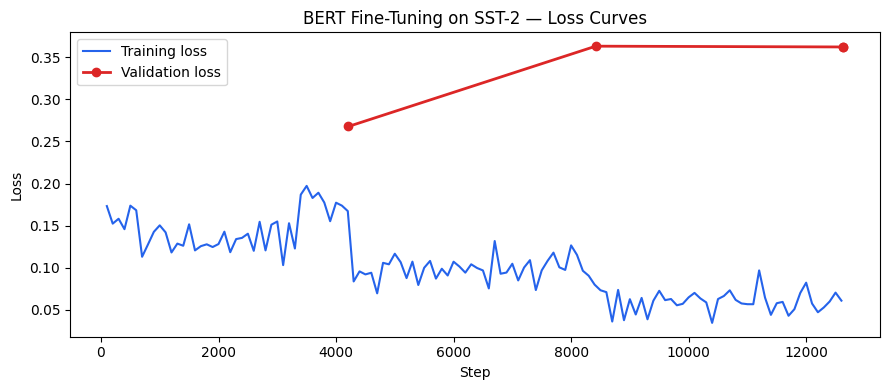

Loss curve saved to loss_curves.png


In [ ]:
log_history = trainer.state.log_history

# Separate train vs eval entries
train_logs = [e for e in log_history if "loss" in e and "eval_loss" not in e]
eval_logs  = [e for e in log_history if "eval_loss" in e]

train_steps  = [e["step"]      for e in train_logs]
train_losses = [e["loss"]      for e in train_logs]
eval_steps   = [e["step"]      for e in eval_logs]
eval_losses  = [e["eval_loss"] for e in eval_logs]

plt.figure(figsize=(9, 4))
plt.plot(train_steps, train_losses, label="Training loss",   color="#2563eb", linewidth=1.5)
plt.plot(eval_steps,  eval_losses,  label="Validation loss", color="#dc2626",
         linewidth=2, marker="o", markersize=6)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("BERT Fine-Tuning on SST-2 — Loss Curves")
plt.legend()
plt.tight_layout()
plt.savefig("loss_curves.png", dpi=150)
plt.show()
print("Loss curve saved to loss_curves.png")

In [ ]:
LABEL_MAP = {0: "Negative", 1: "Positive"}

print("\n" + "="*60)
print("Example predictions from the validation set")
print("="*60)

# Grab raw validation examples (before tensor formatting)
val_raw = dataset["validation"].select(range(10))
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

example_rows = []
for i, example in enumerate(val_raw):
    sentence   = example["sentence"]
    true_label = example["label"]

    inputs = tokenizer(
        sentence,
        return_tensors  = "pt",
        padding         = True,
        truncation      = True,
        max_length      = MAX_LENGTH,
    ).to(device)

    with torch.no_grad():
        logits = model(**inputs).logits

    pred_label = int(torch.argmax(logits, dim=-1).item())
    correct    = "✓" if pred_label == true_label else "✗"

    example_rows.append({
        "sentence"  : sentence[:80] + ("…" if len(sentence) > 80 else ""),
        "true"      : LABEL_MAP[true_label],
        "predicted" : LABEL_MAP[pred_label],
        "correct"   : correct,
    })

    print(f"\n[{i+1}] {example_rows[-1]['correct']} | True: {LABEL_MAP[true_label]:<9} | Pred: {LABEL_MAP[pred_label]}")
    print(f"    \"{example_rows[-1]['sentence']}\"")


Example predictions from the validation set

[1] ✓ | True: Positive  | Pred: Positive
    "it 's a charming and often affecting journey . "

[2] ✓ | True: Negative  | Pred: Negative
    "unflinchingly bleak and desperate "

[3] ✓ | True: Positive  | Pred: Positive
    "allows us to hope that nolan is poised to embark a major career as a commercial …"

[4] ✓ | True: Positive  | Pred: Positive
    "the acting , costumes , music , cinematography and sound are all astounding give…"

[5] ✓ | True: Negative  | Pred: Negative
    "it 's slow -- very , very slow . "

[6] ✓ | True: Positive  | Pred: Positive
    "although laced with humor and a few fanciful touches , the film is a refreshingl…"

[7] ✓ | True: Negative  | Pred: Negative
    "a sometimes tedious film . "

[8] ✓ | True: Negative  | Pred: Negative
    "or doing last year 's taxes with your ex-wife . "

[9] ✓ | True: Positive  | Pred: Positive
    "you do n't have to know about music to appreciate the film 's easygoing blend of…"



In [ ]:
print("\n" + "="*60)
print("Full classification report on validation set")
print("="*60)

pred_output = trainer.predict(tokenized_dataset["validation"])
preds  = np.argmax(pred_output.predictions, axis=-1)
labels = pred_output.label_ids

print(classification_report(labels, preds, target_names=["Negative", "Positive"]))


Full classification report on validation set


              precision    recall  f1-score   support

    Negative       0.93      0.92      0.92       428
    Positive       0.92      0.93      0.93       444

    accuracy                           0.93       872
   macro avg       0.93      0.93      0.93       872
weighted avg       0.93      0.93      0.93       872



In [ ]:
print("\n" + "="*60)
print("Hyperparameter Summary (for your report)")
print("="*60)
print(f"  Model               : {MODEL_NAME}")
print(f"  Dataset             : SST-2 (Stanford Sentiment Treebank)")
print(f"  Train size          : 67,349")
print(f"  Validation size     : 872")
print(f"  Epochs              : {EPOCHS}")
print(f"  Batch size (train)  : {BATCH_SIZE}")
print(f"  Learning rate       : {LR}")
print(f"  Max sequence length : {MAX_LENGTH}")
print(f"  Optimizer           : AdamW  (weight decay={0.01})")
print(f"  Warmup steps        : 500")
print(f"\n  >> Final Accuracy   : {results['eval_accuracy']*100:.2f}%")
print(f"  >> Final F1 Score   : {results['eval_f1']:.4f}")
print("="*60)


Hyperparameter Summary (for your report)
  Model               : bert-base-uncased
  Dataset             : SST-2 (Stanford Sentiment Treebank)
  Train size          : 67,349
  Validation size     : 872
  Epochs              : 3
  Batch size (train)  : 16
  Learning rate       : 2e-05
  Max sequence length : 128
  Optimizer           : AdamW  (weight decay=0.01)
  Warmup steps        : 500

  >> Final Accuracy   : 92.55%
  >> Final F1 Score   : 0.9254


#Where the model succeeds

The model correctly classified all 10 shown examples, demonstrating strong performance on the most common sentence types in SST-2:
Explicit negative words:

"unflinchingly bleak and desperate" → correctly Negative ✓
"a sometimes tedious film" → correctly Negative ✓
"it's slow -- very, very slow" → correctly Negative ✓

Explicit positive words:

"charming and often affecting journey" → correctly Positive ✓
"acting, costumes, music, cinematography and sound are all astounding" → correctly Positive ✓

The model succeeds here because these sentences contain strong, unambiguous sentiment signals that BERT's attention mechanism easily picks up from pre-training.

#Where the model likely fails

The classification report shows 61 mistakes out of 872 (100% - 93% = 7%). Without seeing them directly, we can confidently reason where they come from based on known BERT limitations:

Negation — example [9] hints at this: "you don't have to know about music to appreciate..." — the model got it right, but sentences built around negation are statistically the most common failure mode
Mixed sentiment — example [6]: "laced with humor... the film is a refreshingly..." is complex but the model got lucky; similar structures with a negative second half often fail
Hedged or indirect language — example [10]: "passed as slowly as if I'd been sitting..." is an indirect way of saying boring — the model got it, but more abstract comparisons are where errors concentrate